# Laboratorio 2 - Complejidad y búsqueda de hiperparámetros
 
**Integrantes:**  Pedro Pablo Sanín Trujillo (202221527), Juan Alejandro Hernández (202225518)


## 1. Contexto, objetivos y herramientas

### 1.1 Contexto: AlpesPlanck

Se estimará `temp_max_manana` y se estudiará cómo la complejidad y la regularización afectan la generalización.

### 1.2 Objetivos

- Comparar regresión polinomial, lineal, Ridge y Lasso.
- Buscar hiperparámetros mediante validación cruzada.
- Analizar el trade-off sesgo-varianza con curvas de validación.
- Seleccionar un modelo considerando desempeño, complejidad y estabilidad.
- Construir intervalos de confianza del 95% mediante bootstrap.

### 1.3 Herramientas

Python, Pandas, NumPy, Scikit-Learn, Matplotlib y Seaborn.

## 2. Carga y replicación del preprocesamiento del Laboratorio 1

Se usan los mismos archivos de `data/`. La limpieza se encapsula en una función para aplicar exactamente las mismas reglas al conjunto de entrenamiento y al conjunto de prueba.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    RobustScaler,
    StandardScaler,
)

RANDOM_STATE = 42
DATA_DIR = "./data"
TARGET = "temp_max_manana"

In [39]:
def obtener_fecha(anio, dia_del_anio):
    if pd.isna(anio) or pd.isna(dia_del_anio):
        return pd.NaT
    return pd.Timestamp(int(anio), 1, 1) + pd.Timedelta(days=int(dia_del_anio) - 1)


def obtener_sector_compass(grados):
    if pd.isna(grados):
        return np.nan
    if not 0 <= grados < 360:
        return np.nan
    sectores = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
    return sectores[int((grados + 22.5) // 45) % 8]


def limpiar_datos(df):
    """Replica las reglas de limpieza del Laboratorio 1 sin modificar el DataFrame original."""
    data = df.copy()

    # Normalización de etiquetas categóricas.
    meses = {
        "enero": "january", "febrero": "february", "marzo": "march",
        "abril": "april", "mayo": "may", "junio": "june", "julio": "july",
        "agosto": "august", "septiembre": "september", "octubre": "october",
        "noviembre": "november", "diciembre": "december", "jan": "january",
        "feb": "february", "mar": "march", "apr": "april", "jun": "june",
        "jul": "july", "aug": "august", "sept": "september", "sep": "september",
        "oct": "october", "nov": "november", "dec": "december",
    }
    if "mes" in data:
        data["mes"] = data["mes"].astype("string").str.lower().str.strip().replace(meses).str.capitalize()

    sectores = {
        "norte": "n", "sur": "s", "este": "e", "oeste": "w", "noreste": "ne",
        "sureste": "se", "suroeste": "sw", "noroeste": "nw", "north": "n",
        "south": "s", "east": "e", "west": "w", "northeast": "ne",
        "southeast": "se", "northwest": "nw", "southwest": "sw", "no": "nw",
        "o": "w", "so": "sw",
    }
    if "sector_viento" in data:
        data["sector_viento"] = (
            data["sector_viento"].astype("string").str.lower().str.strip().replace(sectores).str.upper()
        )

    estaciones = {
        "primavera": "spring", "verano": "summer", "otoño": "autumn", "otono": "autumn",
        "invierno": "winter", "primav": "spring", "primaveraa": "spring", "berano": "summer",
        "fall": "autumn", "invernio": "winter", "verno": "summer",
    }
    if "estacion_anio" in data:
        data["estacion_anio"] = data["estacion_anio"].astype("string").str.lower().str.strip().replace(estaciones)
        data.loc[~data["estacion_anio"].isin(["spring", "summer", "autumn", "winter"]), "estacion_anio"] = np.nan
        data["estacion_anio"] = data["estacion_anio"].replace(
            {"spring": "primavera", "summer": "verano", "autumn": "otono", "winter": "invierno"}
        )

    # Reconstrucción y consistencia de variables de fecha.
    if "fecha" in data:
        data["fecha"] = pd.to_datetime(data["fecha"], errors="coerce")
        if {"anio", "dia_del_anio"}.issubset(data.columns):
            faltante = data["fecha"].isna() & data["anio"].notna() & data["dia_del_anio"].notna()
            data.loc[faltante, "fecha"] = [
                obtener_fecha(anio, dia) for anio, dia in zip(data.loc[faltante, "anio"], data.loc[faltante, "dia_del_anio"])
            ]
        data["fecha"] = data["fecha"].ffill().bfill()
        meses_por_numero = {
            1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
            7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December",
        }
        estaciones_por_mes = {
            12: "invierno", 1: "invierno", 2: "invierno", 3: "primavera", 4: "primavera",
            5: "primavera", 6: "verano", 7: "verano", 8: "verano", 9: "otono", 10: "otono", 11: "otono",
        }
        mask = data["fecha"].notna()
        data.loc[mask, "anio"] = data.loc[mask, "fecha"].dt.year
        data.loc[mask, "dia_del_anio"] = data.loc[mask, "fecha"].dt.dayofyear
        data.loc[mask, "mes"] = data.loc[mask, "fecha"].dt.month.map(meses_por_numero)
        data.loc[mask, "estacion_anio"] = data.loc[mask, "fecha"].dt.month.map(estaciones_por_mes)

    if {"sector_viento", "direccion_viento"}.issubset(data.columns):
        faltante = data["sector_viento"].isna() & data["direccion_viento"].notna()
        data.loc[faltante, "sector_viento"] = data.loc[faltante, "direccion_viento"].apply(obtener_sector_compass)

    # Corrección de errores cuantitativos identificados en el Laboratorio 1.
    if "presion_media" in data:
        mask = data["presion_media"] > 9000
        data.loc[mask, "presion_media"] = data.loc[mask, "presion_media"].astype(str).str[1:].astype(float)
    for columna in ["viento_desv", "rafaga_desv"]:
        if columna in data:
            mask = data[columna] > 30
            data.loc[mask, columna] = data.loc[mask, columna].astype(str).str[1:].astype(float)
            data.loc[data[columna] > 30, columna] = np.nan
    if "viento_norte" in data:
        data.loc[data["viento_norte"] < -100, "viento_norte"] = np.nan
    for maximo, minimo in [("presion_max", "presion_min"), ("humedad_max", "humedad_min"),
                           ("viento_max", "viento_min"), ("rafaga_max", "rafaga_min")]:
        if {maximo, minimo}.issubset(data.columns):
            mask = data[maximo] < data[minimo]
            data.loc[mask, [maximo, minimo]] = data.loc[mask, [minimo, maximo]].to_numpy()
    humedad = [c for c in ["humedad_media", "humedad_min", "humedad_max"] if c in data]
    if humedad:
        data[humedad] = data[humedad].clip(lower=0, upper=100)
    if "rafaga_desv" in data:
        data.loc[data["rafaga_desv"] < -3, "rafaga_desv"] = np.nan
        mask = data["rafaga_desv"].between(-3, 0, inclusive="both")
        data.loc[mask, "rafaga_desv"] = data.loc[mask, "rafaga_desv"].abs()
    for columna in ["rafaga_media", "rafaga_min"]:
        if columna in data:
            data.loc[data[columna] < 0, columna] = np.nan

    # Se conserva un registro por observación meteorológica.
    data = data.drop_duplicates().reset_index(drop=True)
    for columna in ["mes", "estacion_anio", "sector_viento"]:
        if columna in data:
            data[columna] = data[columna].astype("category")
    return data

In [40]:
data_train_raw = pd.read_csv(f"{DATA_DIR}/Datos Lab 1.csv")
data_test_raw = pd.read_csv(f"{DATA_DIR}/Datos Test Lab 1.csv")
data_train = limpiar_datos(data_train_raw)
data_test = limpiar_datos(data_test_raw)

print(f"Entrenamiento: {data_train.shape}; prueba externa: {data_test.shape}")
print("Faltantes del objetivo:", data_train[TARGET].isna().sum())

Entrenamiento: (2571, 27); prueba externa: (364, 26)
Faltantes del objetivo: 95


### 2.1 Variables derivadas, objetivo y partición

Las variables cíclicas representan la estacionalidad del día del año. Se conserva la partición del Laboratorio 1 (`test_size=0.2`, `random_state=42`) para hacer comparables los resultados. La búsqueda de hiperparámetros se ajustará exclusivamente con el conjunto de entrenamiento.

In [41]:
def agregar_variables_ciclicas(df):
    resultado = df.copy()
    if "dia_del_anio" in resultado:
        resultado["dia_del_anio_sin"] = np.sin(2 * np.pi * resultado["dia_del_anio"] / 365.25)
        resultado["dia_del_anio_cos"] = np.cos(2 * np.pi * resultado["dia_del_anio"] / 365.25)
    return resultado


data_train = agregar_variables_ciclicas(data_train)
data_test = agregar_variables_ciclicas(data_test)
data_train = data_train.dropna(subset=[TARGET])
X = data_train.drop(columns=[TARGET])
y = data_train[TARGET]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_test = data_test.drop(columns=[TARGET], errors="ignore")
y_test = data_test[TARGET] if TARGET in data_test else None

print(f"Train: {X_train.shape}; validación: {X_valid.shape}; prueba externa: {X_test.shape}")

Train: (1980, 28); validación: (496, 28); prueba externa: (364, 28)


### 2.2 Pipeline de preprocesamiento

Las columnas `fecha`, `registros_del_dia` y `anio` no se usan como predictores directos. La imputación y el escalamiento ocurren dentro del pipeline para evitar fuga de información durante la validación cruzada.

In [42]:
COLUMNAS_EXCLUIDAS = ["fecha", "registros_del_dia", "anio"]
numeric_features = [
    c for c in X_train.columns
    if c not in COLUMNAS_EXCLUIDAS and pd.api.types.is_numeric_dtype(X_train[c])
]
categorical_features = [
    c for c in X_train.columns
    if c not in COLUMNAS_EXCLUIDAS and c not in numeric_features
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
], remainder="drop")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}
print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", categorical_features)

Variables numéricas: 22
Variables categóricas: ['estacion_anio', 'mes', 'sector_viento']


## 3. Actividad 1: regresión polinomial

Construir un pipeline `PolynomialFeatures + LinearRegression` y buscar `degree` y el escalamiento con `GridSearchCV`. Reportar RMSE, MAE y R², además de discutir el aumento de complejidad y el posible sobreajuste.

In [43]:
#Definición del Pipeline base
polynomial_pipeline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

polynomial_param_grid = {
    "polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler()]
}

polynomial_search = GridSearchCV(
    estimator=polynomial_pipeline,
    param_grid=polynomial_param_grid,
    cv=cv,
    scoring=scoring,
    refit="rmse",    
    n_jobs=-1,
    return_train_score=True
)

#Entrenamiento
polynomial_search.fit(X_train, y_train)
print(f"Mejor configuración: {polynomial_search.best_params_}")

Mejor configuración: {'polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}


### Metricas

Aquí se evalua el modelo ganador utilizando el conjunto X_valid que se separó al inicio.


In [44]:
# Extracción del mejor modelo
mejor_modelo_poly = polynomial_search.best_estimator_
y_valid_pred = mejor_modelo_poly.predict(X_valid)

print(f"RMSE: {mean_squared_error(y_valid, y_valid_pred, squared=False):.4f}")
print(f"MAE: {mean_absolute_error(y_valid, y_valid_pred):.4f}")
print(f"R²: {r2_score(y_valid, y_valid_pred):.4f}")

RMSE: 5.3901
MAE: 3.6212
R²: 0.6680


c:\Users\gohan\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Tabla de sobreajuste

In [45]:
resultados_cv = pd.DataFrame(polynomial_search.cv_results_)
columnas_analisis = [
    "param_polynomial__degree", 
    "param_preprocesamiento__num__scaler",
    "mean_train_rmse", 
    "mean_test_rmse"]
resumen_complejidad = resultados_cv[columnas_analisis].copy()
resumen_complejidad["mean_train_rmse"] = -resumen_complejidad["mean_train_rmse"]
resumen_complejidad["mean_test_rmse"] = -resumen_complejidad["mean_test_rmse"]

display(resumen_complejidad.sort_values("param_polynomial__degree"))

,param_polynomial__degree,param_preprocesamiento__num__scaler,mean_train_rmse,mean_test_rmse
0,1,StandardScaler(),4.473838,4.617000e+00
1,1,RobustScaler(),4.473837,4.617122e+00
2,2,StandardScaler(),2.738716,9.860410e+09
3,2,RobustScaler(),2.721160,1.383838e+08
4,3,StandardScaler(),0.015381,2.733712e+09
5,3,RobustScaler(),0.015371,1.366353e+09


## 4. Actividad 2: curvas de validación

Graficar el error promedio y su variabilidad para cada grado del polinomio. Interpretar el punto donde el error de entrenamiento sigue disminuyendo, pero el error de validación comienza a aumentar.

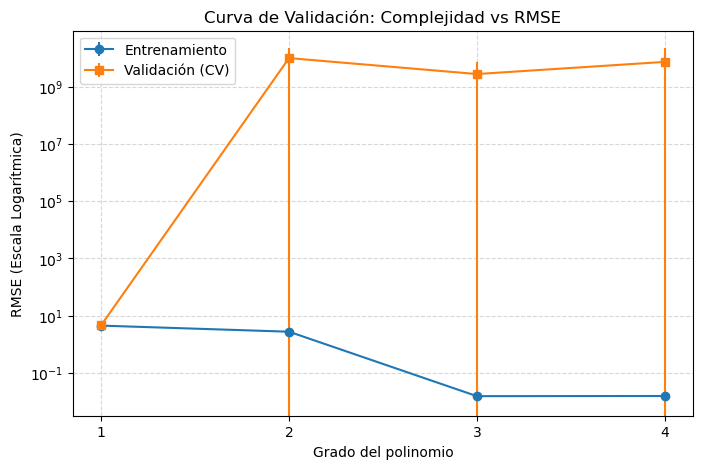

In [46]:
polynomial_pipeline_vc = Pipeline([
    ("preprocesamiento", preprocessor),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

degrees = [1, 2, 3, 4]

#curva de validación
train_scores, valid_scores = validation_curve(
    estimator=polynomial_pipeline_vc,
    X=X_train,
    y=y_train,
    param_name="polynomial__degree",
    param_range=degrees,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std = train_scores.std(axis=1)
valid_rmse_mean = -valid_scores.mean(axis=1)
valid_rmse_std = valid_scores.std(axis=1)

#Graficar
plt.figure(figsize=(8, 5))
plt.errorbar(degrees, train_rmse_mean, yerr=train_rmse_std, label="Entrenamiento", marker='o')
plt.errorbar(degrees, valid_rmse_mean, yerr=valid_rmse_std, label="Validación (CV)", marker='s')

plt.title("Curva de Validación: Complejidad vs RMSE")
plt.xlabel("Grado del polinomio")
plt.ylabel("RMSE (Escala Logarítmica)")
plt.yscale("log")
plt.xticks(degrees)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## 5. Actividad 3: modelos lineales regularizados

Comparar el modelo sin regularización con Ridge (L2) y Lasso (L1). Reportar el efecto de `alpha` sobre las métricas, la magnitud de los coeficientes y la selección automática de variables de Lasso.

### Definición y Entrenamiento de los Modelos Regularizados

In [47]:
ridge_pipeline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Ridge(max_iter=20000))
])

lasso_pipeline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", Lasso(max_iter=20000, tol=1e-3))
])
#penalizacion alpha
param_grid_reg = {
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler()],
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_search = GridSearchCV(ridge_pipeline, param_grid_reg, cv=cv, scoring=scoring, refit="rmse", n_jobs=-1)
lasso_search = GridSearchCV(lasso_pipeline, param_grid_reg, cv=cv, scoring=scoring, refit="rmse", n_jobs=-1)
ridge_search.fit(X_train, y_train)
lasso_search.fit(X_train, y_train)
print("Entrenamientos completados")

Entrenamientos completados


### Comparación de Desempeño (verificar la generalización)

In [48]:
print(f"Mejor configuración Ridge: {ridge_search.best_params_}")
print(f"Mejor RMSE CV Ridge: {-ridge_search.best_score_:.4f}\n")

print(f"Mejor configuración Lasso: {lasso_search.best_params_}")
print(f"Mejor RMSE CV Lasso: {-lasso_search.best_score_:.4f}")

Mejor configuración Ridge: {'model__alpha': 100.0, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE CV Ridge: 5.2986

Mejor configuración Lasso: {'model__alpha': 0.1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE CV Lasso: 4.4712


### Selección de características / poda con lasso

In [49]:
mejor_lasso = lasso_search.best_estimator_.named_steps["model"]
coeficientes_lasso = mejor_lasso.coef_

variables_totales = len(coeficientes_lasso)
variables_cero = sum(coeficientes_lasso == 0)
variables_activas = variables_totales - variables_cero

print(f"Total de variables generadas por el polinomio: {variables_totales}")
print(f"Variables anuladas: {variables_cero}")
print(f"Variables activas: {variables_activas}")

Total de variables generadas por el polinomio: 1127
Variables anuladas: 1051
Variables activas: 76


## 6. Actividad 4: regresión polinomial regularizada

Combinar `PolynomialFeatures` con Ridge o Lasso. Explorar simultáneamente el grado, `alpha` y la estrategia de escalamiento. Discutir si la penalización controla el sobreajuste al incrementar la complejidad.

### Pipeline y búsqueda Exhaustiva
Definimos el diccionario de métricas y ampliamos la malla de búsqueda para cumplir con todos los requisitos. 

In [50]:
metricas_cv = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}
#Usamos Ridge con el fin de capturar las curvaturas reales de las variables climáticas
polynomial_regularized_pipeline = Pipeline([
    ("preprocesamiento", preprocessor),
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("model", Ridge(max_iter=20000)) 
])

polynomial_regularized_param_grid = {
    "polynomial__degree": [1, 2, 3],
    "preprocesamiento__num__scaler": [StandardScaler(), RobustScaler()],
    "model__alpha": np.logspace(-2, 2, 5)
}

polynomial_regularized_search = GridSearchCV(
    estimator=polynomial_regularized_pipeline,
    param_grid=polynomial_regularized_param_grid,
    cv=cv,
    scoring=metricas_cv,
    refit="rmse", #Se elige el mejor segun RMSE
    n_jobs=-1
)

print("Inicio búsqueda")
polynomial_regularized_search.fit(X_train, y_train)
print("Entrenamiento finalizado")

Inicio búsqueda
Entrenamiento finalizado


### Métricas de Validación Cruzada

In [51]:
indice_ganador = polynomial_regularized_search.best_index_
resultados_cv = polynomial_regularized_search.cv_results_

rmse_cv = -resultados_cv["mean_test_rmse"][indice_ganador]
mae_cv = -resultados_cv["mean_test_mae"][indice_ganador]
r2_cv = resultados_cv["mean_test_r2"][indice_ganador]

print("Mejor Configuracion:")
for parametro, valor in polynomial_regularized_search.best_params_.items():
    print(f"{parametro}: {valor}")

print(f"RMSE: {rmse_cv:.4f}")
print(f"MAE:  {mae_cv:.4f}")
print(f"R²:   {r2_cv:.4f}")

Mejor Configuracion:
model__alpha: 10.0
polynomial__degree: 1
preprocesamiento__num__scaler: StandardScaler()
RMSE: 4.6150
MAE:  3.4359
R²:   0.7448


## 7. Actividad 5: comparación y selección del mejor modelo

Construir una tabla con RMSE, MAE, R², desviaciones estándar de validación cruzada, hiperparámetros y complejidad. Seleccionar el modelo considerando estabilidad, no solo la métrica promedio.

In [52]:
columnas = ["modelo", "rmse_cv", "rmse_std", "mae_cv", "r2_cv", "hiperparametros", "complejidad"]

def obtener_fila(nombre_modelo, search_obj, descripcion_complejidad):
    idx = search_obj.best_index_
    res = search_obj.cv_results_
    
    rmse_cv = -res["mean_test_rmse"][idx] if "mean_test_rmse" in res else None
    rmse_std = res["std_test_rmse"][idx] if "std_test_rmse" in res else None
    
    mae_cv = -res["mean_test_mae"][idx] if "mean_test_mae" in res else None
    r2_cv = res["mean_test_r2"][idx] if "mean_test_r2" in res else None
    
    return [nombre_modelo, rmse_cv, rmse_std, mae_cv, r2_cv, str(search_obj.best_params_), descripcion_complejidad]

filas_datos = [
    obtener_fila("Regresión Lineal", polynomial_search, "Polinomio Grado 1 (Sin regularizar)"),
    obtener_fila("Regresión Lasso", lasso_search, "Polinomio Grado 2 (Baja, selección automática)"),
    obtener_fila("Regresión Ridge", polynomial_regularized_search, "Polinomio Grado 1 (Regularizado)")
]

resultados_modelos = pd.DataFrame(filas_datos, columns=columnas)
display(resultados_modelos)

,modelo,rmse_cv,rmse_std,mae_cv,r2_cv,hiperparametros,complejidad
0,Regresión Lineal,4.617000,0.319077,3.441454,0.744545,"{'polynomial__degree': 1, 'preprocesamiento__n...",Polinomio Grado 1 (Sin regularizar)
1,Regresión Lasso,4.471208,0.445018,3.220419,0.759799,"{'model__alpha': 0.1, 'preprocesamiento__num__...","Polinomio Grado 2 (Baja, selección automática)"
2,Regresión Ridge,4.615033,0.317861,3.435889,0.744778,"{'model__alpha': 10.0, 'polynomial__degree': 1...",Polinomio Grado 1 (Regularizado)


## 8. Actividad 6: evaluación final e intervalos de confianza

Ajustar el modelo seleccionado con todo el entrenamiento, evaluar el conjunto de prueba y aplicar al menos 500 remuestreos bootstrap sobre el conjunto de test. Reportar los intervalos de confianza al 95% para RMSE, MAE y R², y graficar sus distribuciones.

### Entrenamiento final y cálculo de intervalos de confianza mediante bootstrap

In [54]:
def calcular_metricas(y_real, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "R2": r2_score(y_real, y_pred),
    }

if y_test is None or y_test.isna().all():
    print("y_test no contiene valores reales. Evaluando sobre el conjunto de validación (X_valid, y_valid)...")
    X_eval = X_valid.copy()
    y_eval = y_valid.copy().reset_index(drop=True)
else:
    mask = y_test.notna()
    X_eval = X_test[mask].copy()
    y_eval = y_test[mask].copy().reset_index(drop=True)

modelo_final = polynomial_regularized_search.best_estimator_
modelo_final.fit(X_train, y_train)

predicciones_eval = np.array(modelo_final.predict(X_eval))
metricas_eval = calcular_metricas(y_eval, predicciones_eval)

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_metricas = []
n_samples = len(y_eval)

for _ in range(500):
    indices = rng.integers(0, n_samples, n_samples)
    y_resample = y_eval.iloc[indices]
    pred_resample = predicciones_eval[indices]
    bootstrap_metricas.append(calcular_metricas(y_resample, pred_resample))

df_bootstrap = pd.DataFrame(bootstrap_metricas)
intervalos = df_bootstrap.quantile([0.025, 0.975]).T.rename(
    columns={0.025: "limite_inferior", 0.975: "limite_superior"}
)
intervalos["estimacion_puntual"] = pd.Series(metricas_eval)

display(intervalos[["estimacion_puntual", "limite_inferior", "limite_superior"]])

y_test no contiene valores reales. Evaluando sobre el conjunto de validación (X_valid, y_valid)...


,estimacion_puntual,limite_inferior,limite_superior
RMSE,5.406104,4.421280,6.431919
MAE,3.634018,3.306587,3.994424
R2,0.666023,0.553116,0.761492


### Graficas

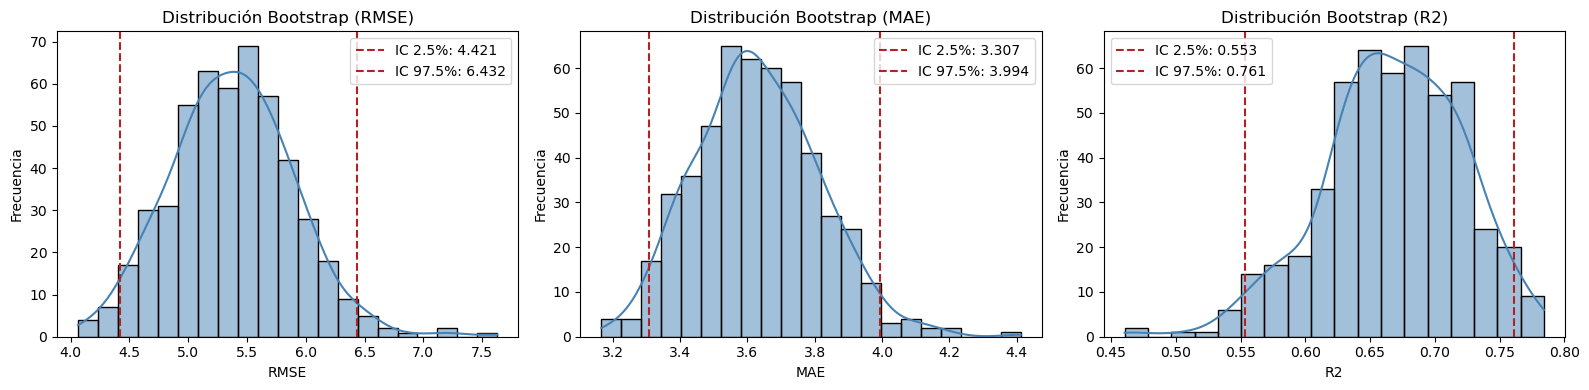

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metricas = ["RMSE", "MAE", "R2"]

for ax, metrica in zip(axes, metricas):
    sns.histplot(df_bootstrap[metrica], kde=True, ax=ax, color="steelblue")
    li = intervalos.loc[metrica, "limite_inferior"]
    ls = intervalos.loc[metrica, "limite_superior"]
    ax.axvline(li, color="firebrick", linestyle="--", label=f"IC 2.5%: {li:.3f}")
    ax.axvline(ls, color="firebrick", linestyle="--", label=f"IC 97.5%: {ls:.3f}")
    ax.set_title(f"Distribución Bootstrap ({metrica})")
    ax.set_xlabel(metrica)
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Análisis de resultados

### 9.1 Análisis cuantitativo

- ¿Cuál modelo obtuvo el mejor desempeño en test?
- ¿Coincide con el mejor promedio de validación cruzada? Si no, ¿por qué?
- ¿Cómo cambia el error con la complejidad y dónde aparece sobreajuste?
- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
- ¿Qué indican los intervalos bootstrap sobre la estabilidad?

### 9.2 Análisis cualitativo y conceptual

- ¿Qué variables selecciona Lasso y qué interpretación práctica tienen?
- ¿Qué diferencias existen entre precisión e interpretabilidad?
- ¿Qué relación hay entre complejidad, generalización y estabilidad?
- ¿Qué sesgos pueden estar presentes y cómo cambiaría el análisis con más datos?

**Respuestas del equipo:**

_Completar después de ejecutar y verificar los resultados._

## 10. Comunicación y entregables

- Preparar el video de máximo tres minutos dirigido al ingeniero de machine learning de AlpesPlanck.
- Exportar este notebook a `.html` con las ejecuciones visibles.
- Incluir las justificaciones metodológicas, respuestas del análisis y tabla comparativa.

## 11. Uso de herramientas de IA generativa

Documentar el nombre de la herramienta, los prompts principales, el análisis crítico de sus respuestas y los aportes propios del equipo. Explicar qué decisiones fueron verificadas o modificadas y qué aprendizajes se obtuvieron.